# **E-Commerce Data Analysis Portfolio Project**

### Introduction: 
In today's rapidly evolving digital marketplace, understanding customer behavior, sales trends, and product dynamics is crucial for business success. 
This portfolio project focuses on data-driven insights derived from a comprehensive e-commerce dataset, sourced from Kaggle. 
Through advanced data visualization techniques, this analysis uncovers key trends that inform strategic decision-making, optimizing business performance and enhancing market understanding.

### Project Objectives:
- Utilize data visualization to reveal patterns in sales, customer preferences, and product demand, without deep statistical analysis.
- Identify growth opportunities by analyzing transaction behaviors across different dimensions.
- Offer actionable recommendations that can help businesses refine their strategies, improve sales performance, and enhance customer engagement.

### Dataset Overview:
The dataset consists of six tables, structured into one fact table and multiple dimension tables, facilitating a multi-faceted view of e-commerce transactions:\
1️⃣ Fact Table: fact_table.csv – Holds core transaction details.\
2️⃣ Dimension Tables:
- customer_dim.csv – Customer-related information.
- item_dim.csv – Product-specific details.
- store_dim.csv – Store locations and data.
- time_dim.csv – Temporal aspects of transactions.
- trans_dim.csv – Transaction metadata.
Through meticulous analysis and visualization, this project provides a deeper understanding of customer behavior, supplier efficiency, and transaction trends, ultimately enabling data-backed business improvements.

Note :  Original dataset is from "https://www.kaggle.com/datasets/mmohaiminulislam/ecommerce-data-analysis/data"


In [70]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # Data visualization
import seaborn as sns # Advance data visualization
import sqlite3 as sql
# import plotly.express as plx pip install # Data Visualization
import warnings
warnings.filterwarnings("ignore")

In [71]:
import pandas as pd

github_folder_path = "https://raw.githubusercontent.com/Paingst12/ECommerce_Analysis-by-python/main/"

print("🔄 Loading CSV file from GitHub...")

fact = pd.read_csv(github_folder_path + "fact_table.csv", encoding='ISO-8859-1')
customer_d = pd.read_csv(github_folder_path + "customer_dim.csv", encoding='ISO-8859-1')
item_d = pd.read_csv(github_folder_path + "item_dim.csv", encoding='ISO-8859-1')
store_d = pd.read_csv(github_folder_path + "store_dim.csv", encoding='ISO-8859-1')
time_d = pd.read_csv(github_folder_path + "time_dim.csv", encoding='ISO-8859-1')
trans_d = pd.read_csv(github_folder_path + "Trans_dim.csv", encoding='ISO-8859-1')

print("✅ All CSV files are loaded as Python Variables from GitHub.")



🔄 Loading CSV file from GitHub...
✅ All CSV files are loaded as Python Variables from GitHub.


## **Customer_Dim Table**:

<details>
    <summary>Click here for Customer_Dim Table info</summary>

### **customer_key**:
* Description: An identifier representing a unique customer.
* Use Case: Serves as the primary key to link with the fact table, allowing for easy and efficient retrieval of customer-specific information.

### **name**:
* Description: The name of the customer.
* Use Case: Captures the personal or business name of the customer for identification and reference purposes.

### **contact_no**:
* Description: The contact number associated with the customer.
* Use Case: Stores the phone number or contact details for communication or outreach purposes.

### **nid**:
* Description: The National ID (NID) or a unique identification number for the customer.


In [72]:
customer_d.head()

,coustomer_key,name,contact_no,nid
0,C000001,sumit,8801920345851,7505075708899
1,C000002,tammanne,8801817069329,1977731324842
2,C000003,kailash kumar,8801663795774,3769494056318
3,C000004,bhagwati prasad,8801533627961,9378834712725
4,C000005,ajay,8801943715786,3540815556323


In [73]:
customer_d.info()

<class 'pandas.DataFrame'>
RangeIndex: 9191 entries, 0 to 9190
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   coustomer_key  9191 non-null   str  
 1   name           9164 non-null   str  
 2   contact_no     9191 non-null   int64
 3   nid            9191 non-null   int64
dtypes: int64(2), str(2)
memory usage: 287.3 KB


In [74]:
customer_d.isnull().sum()

coustomer_key     0
name             27
contact_no        0
nid               0
dtype: int64

In [75]:
# check null value in each row
customer_d[customer_d.isnull().any(axis=1)].head()


,coustomer_key,name,contact_no,nid
136,C000137,NaN,8801554462380,2427034079235
879,C000880,NaN,8801589489843,5352982182049
1170,C001171,NaN,8801951659666,3470353736651
1228,C001229,NaN,8801815330888,6854481831541
1267,C001268,NaN,8801534271305,2195826394727


In [76]:
customer_d[customer_d.duplicated(subset=['name'])]


,coustomer_key,name,contact_no,nid
21,C000022,rahul,8801918987737,7788784415686
27,C000028,vansu dev,8801712578164,5389305491490
39,C000040,rohit,8801687111649,2250720242634
62,C000063,rahul,8801512878636,9533375494747
77,C000078,ramvilash,8801759073688,6720482051449
...,...,...,...,...
9182,C009183,anita,8801685909096,6965233356910
9183,C009184,resham,8801845018438,9519773518987
9185,C009186,sajida,8801773401829,8156888113414
9189,C009190,pintu devi,8801563290767,7234328323528


### Customer Dim Table, data wrangling

There are 27 null values in name column and replaced randomly by Top 5 most frequent object value. 
Renamed coustomer_key to customer_key

In [77]:
customer_d = customer_d.rename(columns={'coustomer_key': 'customer_key'})

In [78]:
# Check the distribution of customer names
customer_d["name"].value_counts()

name
pooja                                                185
jyoti                                                117
neha                                                  87
poonam                                                81
sunita                                                80
                                                    ... 
jhingi d/o hago barjo r/o vill. murchi, post+p.s.      1
krishana yadav                                         1
smt radha                                              1
tulsi sharma                                           1
madhubala                                              1
Name: count, Length: 4534, dtype: int64

In [79]:
# Check the top 5 most common customer names and set into list
top_5_names = customer_d['name'].value_counts().index[:5].tolist()
top_5_names

['pooja', 'jyoti', 'neha', 'poonam', 'sunita']

In [80]:
# Fill the missing values in the 'name' column randomly from 'top_5_names' by using numpy's random.choice() function. 
# This will help to maintain the distribution of names in the dataset while filling in the missing values.
customer_d['name'] = customer_d['name'].apply(lambda x: np.random.choice(top_5_names) if pd.isna(x) else x)

customer_d['name'].isnull().sum()

np.int64(0)

In [81]:
customer_d['name'].value_counts()


name
pooja                                                190
jyoti                                                120
neha                                                  92
sunita                                                88
poonam                                                87
                                                    ... 
jhingi d/o hago barjo r/o vill. murchi, post+p.s.      1
krishana yadav                                         1
smt radha                                              1
tulsi sharma                                           1
madhubala                                              1
Name: count, Length: 4534, dtype: int64

## **Item_Dim Table**:

<details>
    <summary>Click here for Item_Dim Table info</summary>

### **item_key**:
* Description: An identifier representing a unique item or product.
* Use Case: Serves as the primary key to link with the fact table, enabling retrieval of detailed information about specific items in transactions.

### **item_name**:
* Description: The name or title of the item.
* Use Case: Captures the descriptive name of the item, providing a recognizable label for the product.

### **desc**:
* Description: A description of the item.
* Use Case: Contains additional details about the item, such as features, specifications, or any relevant information.

### **unit_price**:
* Description: The price per unit of the item.
* Use Case: Represents the cost or price associated with each unit of the item.

### **man_country**:
* Description: The country where the item is manufactured.
* Use Case: Captures the origin or manufacturing location of the item.

### **supplier**:
* Description: The supplier or vendor providing the item.
* Use Case: Stores the name or identifier of the supplier, facilitating tracking of item sources.

### **unit**:
* Description: The unit of measurement associated with the item (e.g., pieces, kilograms).
```

In [82]:
item_d.head()

,item_key,item_name,desc,unit_price,man_country,supplier,unit
0,I00001,A&W Root Beer - 12 oz cans,a. Beverage - Soda,11.50,Netherlands,Bolsius Boxmeer,cans
1,I00002,A&W Root Beer Diet - 12 oz cans,a. Beverage - Soda,6.75,poland,CHROMADURLIN S.A.S,cans
2,I00003,Barq's Root Beer - 12 oz cans,a. Beverage - Soda,6.75,Bangladesh,DENIMACH LTD,cans
3,I00004,Cherry Coke 12oz,a. Beverage - Soda,6.75,Netherlands,Bolsius Boxmeer,cans
4,I00005,Cherry Coke Zero 12 pack,a. Beverage - Soda,6.75,Finland,HARDFORD AB,cans


In [83]:
item_d.info()

<class 'pandas.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   item_key     264 non-null    str    
 1   item_name    264 non-null    str    
 2   desc         264 non-null    str    
 3   unit_price   264 non-null    float64
 4   man_country  264 non-null    str    
 5   supplier     264 non-null    str    
 6   unit         263 non-null    str    
dtypes: float64(1), str(6)
memory usage: 14.6 KB


### Item_Dim Table, data wrangling

There is one null value in unit column and replaced by maximum counted object value. 

In [84]:
item_d.isnull().sum()

item_key       0
item_name      0
desc           0
unit_price     0
man_country    0
supplier       0
unit           1
dtype: int64

In [85]:
item_d[item_d.isnull().any(axis=1)]

,item_key,item_name,desc,unit_price,man_country,supplier,unit
157,I00158,Frito Bold Flavors Variety,Food - Chips,17.0,Lithuania,BIGSO AB,NaN


In [86]:
item_d["item_name"].value_counts()

item_name
Coke Classic 12 oz cans                  2
Diet Coke - 12 oz cans                   2
Pepsi - 12 oz cans                       2
Sprite - 12 oz cans                      2
Muscle Milk Protein Shake Van. 11oz      2
                                        ..
Napkins Square Lunch                     1
POM 2 ply paper towels                   1
Strong Everyday Napkins                  1
Advil 2 pill packets                     1
Tylenol Extra Strength 2 pill packets    1
Name: count, Length: 259, dtype: int64

In [87]:
item_d["unit"].isnull().sum()

np.int64(1)

In [88]:
# Fill the missing values in the 'unit' column with the most common unit value in the dataset.
# By using numpy's value_counts() and np.nan to find the most common unit value and replace the missing values with it.
common_item_unit = item_d["unit"].value_counts().idxmax()
item_d["unit"] = item_d["unit"].replace(np.nan,common_item_unit)

In [89]:
# Previously, the missing values in the 'unit' column at index 157 were filled with the most common unit value. 
# Let's check if there are any remaining missing values in the 'unit' column.

item_d["unit"].isnull().sum()
item_d.iloc[157]

item_key                           I00158
item_name      Frito Bold Flavors Variety
desc                         Food - Chips
unit_price                           17.0
man_country                     Lithuania
supplier                         BIGSO AB
unit                                   ct
Name: 157, dtype: object

In [90]:
item_d['unit'].value_counts()

unit
ct          95
cans        57
bottles     37
oz          19
bags        13
pk          10
ct.          8
bars         5
pack         5
tubs         3
Bags         3
rolls        2
Ct           2
botlltes     1
cartons      1
oz.          1
lb           1
tins         1
Name: count, dtype: int64

## **Store_Dim Table**:

<details>
    <summary>Click here for Store_Dim Table info</summary>

### **store_key**:
* Description: An identifier representing a unique store or location.
* Use Case: Serves as the primary key to link with the fact table, allowing for easy retrieval of information about transactions associated with specific stores.

### **division**:
* Description: The administrative division or region where the store is located.
* Use Case: Captures the broader geographical area in which the store operates.

### **district**:
* Description: The district where the store is situated.
* Use Case: Specifies a more localized geographical area, providing information about the district where the store is located.

### **upazila**:
* Description: The upazila or sub-district where the store is situated.
* Use Case: Represents a more granular geographical location, providing details 


In [91]:
store_d.info()

<class 'pandas.DataFrame'>
RangeIndex: 726 entries, 0 to 725
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   store_key  726 non-null    str  
 1   division   726 non-null    str  
 2   district   726 non-null    str  
 3   upazila    726 non-null    str  
dtypes: str(4)
memory usage: 22.8 KB


In [92]:
store_d.isnull().sum()


store_key    0
division     0
district     0
upazila      0
dtype: int64

In [93]:
store_d.head()

,store_key,division,district,upazila
0,S0001,SYLHET,HABIGANJ,AJMIRIGANJ
1,S0002,SYLHET,HABIGANJ,BAHUBAL
2,S0003,SYLHET,HABIGANJ,BANIACHONG
3,S0004,SYLHET,HABIGANJ,CHUNARUGHAT
4,S0005,SYLHET,HABIGANJ,HABIGANJ SADAR


## **Time_Dim Table**:

<details>
    <summary>Click here for Time_Dim Table info</summary>

### **time_keyy**:
* Description: An identifier representing a unique time or timestamp.
* Use Case: Serves as the primary key to link with the fact table, allowing for easy and efficient retrieval of information about transactions based on time.

### **date**:
* Description: The specific date associated with the timestamp.
* Use Case: Captures the calendar date corresponding to the time key, providing information about when a transaction occurred.

### **hour**:
* Description: The hour component of the timestamp.
* Use Case: Represents the specific hour of the day when a transaction took place, allowing for time-based analysis.

### **day**:
* Description: The day of the week associated with the timestamp.
* Use Case: Provides information about the day of the week for more granular time-based analysis.

### **week**:
* Description: The week number associated with the timestamp.
* Use Case: Captures the week in the calendar year when a transaction occurred, facilitating weekly analysis.

### **month**:
* Description: The month associated with the timestamp.
* Use Case: Represents the calendar month when a transaction took place, enabling monthly analysis.

### **quarter**:
* Description: The quarter of the year associated with the timestamp.
* Use Case: Captures the quarter in the calendar year when a transaction occurred, facilitating quarterly analysis.

### **year**:
* Description: The calendar year associated with the timestamp.

In [94]:
time_d.info()

<class 'pandas.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   time_key  99999 non-null  str  
 1   date      99999 non-null  str  
 2   hour      99999 non-null  int64
 3   day       99999 non-null  int64
 4   week      99999 non-null  str  
 5   month     99999 non-null  int64
 6   quarter   99999 non-null  str  
 7   year      99999 non-null  int64
dtypes: int64(4), str(4)
memory usage: 6.1 MB


### Time_Dim Table, data wrangling

There is object data type at date column and change data type as Datetime. 

In [95]:
time_d.head()

,time_key,date,hour,day,week,month,quarter,year
0,T00001,20-05-2017 14:56,14,20,3rd Week,5,Q2,2017
1,T00002,30-01-2015 22:14,22,30,4th Week,1,Q1,2015
2,T00003,14-03-2020 02:34,2,14,2nd Week,3,Q1,2020
3,T00004,27-04-2018 12:19,12,27,4th Week,4,Q2,2018
4,T00005,14-04-2018 10:43,10,14,2nd Week,4,Q2,2018


In [96]:
time_d["date"] = pd.to_datetime(time_d['date'])
time_d.info()

<class 'pandas.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   time_key  99999 non-null  str           
 1   date      99999 non-null  datetime64[us]
 2   hour      99999 non-null  int64         
 3   day       99999 non-null  int64         
 4   week      99999 non-null  str           
 5   month     99999 non-null  int64         
 6   quarter   99999 non-null  str           
 7   year      99999 non-null  int64         
dtypes: datetime64[us](1), int64(4), str(3)
memory usage: 6.1 MB


In [97]:
time_d.head()

,time_key,date,hour,day,week,month,quarter,year
0,T00001,2017-05-20 14:56:00,14,20,3rd Week,5,Q2,2017
1,T00002,2015-01-30 22:14:00,22,30,4th Week,1,Q1,2015
2,T00003,2020-03-14 02:34:00,2,14,2nd Week,3,Q1,2020
3,T00004,2018-04-27 12:19:00,12,27,4th Week,4,Q2,2018
4,T00005,2018-04-14 10:43:00,10,14,2nd Week,4,Q2,2018


In [98]:
time_d.isnull().sum()

time_key    0
date        0
hour        0
day         0
week        0
month       0
quarter     0
year        0
dtype: int64

## **Transaction_Dim Table (Payment)**:

<details>
    <summary>Click here for Transaction_Dim Table info</summary>

### **payment_key**:
* Description: An identifier representing a unique payment transaction.
* Use Case: Serves as the primary key to link with the fact table, allowing for easy and efficient retrieval of information about transactions based on payment.

### **trans_type**:
* Description: The type or method of payment used for the transaction.
* Use Case: Captures the specific payment method employed, such as credit card, cash, or other forms of payment.

### **bank_name**:
* Description: The name of the bank associated with the payment transaction.
* Use Case: Specifies the financial institution or bank involved in processing the payment, providing additional details about the transaction.


In [99]:
trans_d.info()

<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   payment_key  39 non-null     str  
 1   trans_type   39 non-null     str  
 2   bank_name    38 non-null     str  
dtypes: str(3)
memory usage: 1.0 KB


In [100]:
trans_d.head()

,payment_key,trans_type,bank_name
0,P001,cash,NaN
1,P002,card,AB Bank Limited
2,P003,card,Bangladesh Commerce Bank Limited
3,P004,card,Bank Asia Limited
4,P005,card,BRAC Bank Limited


In [101]:
trans_d.isnull().sum()

payment_key    0
trans_type     0
bank_name      1
dtype: int64

### Transaction_Dim Table, data wrangling

There is null at bank_name column and changed to unknown. 

In [102]:
trans_d.replace(np.nan,"unknown",inplace=True)
trans_d.head()

,payment_key,trans_type,bank_name
0,P001,cash,unknown
1,P002,card,AB Bank Limited
2,P003,card,Bangladesh Commerce Bank Limited
3,P004,card,Bank Asia Limited
4,P005,card,BRAC Bank Limited


## **Fact Table**:

<details>
    <summary>Click here for Fact Table info</summary>

### **payment_key**:
    Description: An identifier representing the payment transaction associated with the fact.
    Use Case: This key links to a payment dimension table, providing details about the payment method and related information.

### **customer_key**:
* Description: An identifier representing the customer associated with the fact.
* Use Case: This key links to a customer dimension table, providing details about the customer, such as name, address, and other customer-specific information.

### **time_key**:
* Description: An identifier representing the time dimension associated with the fact.
* Use Case: This key links to a time dimension table, providing details about the time of the transaction, such as date, day of the week, and month.

### **item_key**:
* Description: An identifier representing the item or product associated with the fact.
* Use Case: This key links to an item dimension table, providing details about the product, such as category, sub-category, and product name.

### **store_key**:
* Description: An identifier representing the store or location associated with the fact.
* Use Case: This key links to a store dimension table, providing details about the store, such as location, store name, and other store-specific information.

### **quantity**:
* Description: The quantity of items sold or involved in the transaction.
* Use Case: Represents the amount or number of items associated with the transaction.

### **unit**:
* Description: The unit or measurement associated with the quantity (e.g., pieces, kilograms).
* Use Case: Specifies the unit of measurement for the quantity.

### **unit_price**:
* Description: The price per unit of the item.
* Use Case: Represents the cost or price associated with each unit of the item.

### **total_price**:
* Description: The total price of the transaction, calculated as the product of quantity and unit price.
* Use Case: Represents the overall cost or revenue generated by the transaction.


In [103]:
fact.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   payment_key    1000000 non-null  str    
 1   coustomer_key  1000000 non-null  str    
 2   time_key       1000000 non-null  str    
 3   item_key       1000000 non-null  str    
 4   store_key      1000000 non-null  str    
 5   quantity       1000000 non-null  int64  
 6   unit           996277 non-null   str    
 7   unit_price     1000000 non-null  float64
 8   total_price    1000000 non-null  float64
dtypes: float64(2), int64(1), str(6)
memory usage: 68.7 MB


In [104]:
fact.head()

,payment_key,coustomer_key,time_key,item_key,store_key,quantity,unit,unit_price,total_price
0,P026,C004510,T049189,I00177,S00307,1,ct,35.0,35.0
1,P022,C008967,T041209,I00248,S00595,1,rolls,26.0,26.0
2,P030,C007261,T03633,I00195,S00496,8,ct,12.5,100.0
3,P032,C007048,T084631,I00131,S0086,8,ct,14.0,112.0
4,P014,C006430,T071276,I00050,S00488,8,cans,8.0,64.0


In [105]:
fact.describe()

,quantity,unit_price,total_price
count,1000000.000000,1000000.000000,1000000.000000
mean,6.000185,17.561602,105.401436
std,3.161932,8.637097,80.829301
min,1.000000,6.000000,6.000000
25%,3.000000,13.000000,47.250000
50%,6.000000,16.000000,90.000000
75%,9.000000,20.000000,144.000000
max,11.000000,55.000000,605.000000


### Fact Table, data wrangling

There is renamed coustomer_key column to customer_key. 

In [106]:
# Assuming your DataFrame is called 'df'
fact = fact.rename(columns={'coustomer_key': 'customer_key'})

## **Merge the tables by Relational Data Base Management System in SQL by python**

* Merge *Fact Table* of customer_key(Foreign Key)  with *Customer_Dim Table* on customer_key(Primary Key)
* Merge *Fact Table* of item_key(Foreign Key)  with *Item_Dim Table* on item_key(Primary Key)
* Merge *Fact Table* of store_key(Foreign Key)  with *Store_Dim Table* on store_key(Primary Key)
* Merge *Fact Table* of time_key(Foreign Key)  with *Time_Dim Table* on time_key(Primary Key)
* Merge *Fact Table* of payment_key(Foreign Key)  with *Transaction_Dim Table* on payment_key(Primary Key)





* create "ECommerce_DataBase.db" and import all pandas Tables to SQL by sqlite3 
* Make connection between sql and python


In [107]:
import sqlite3

# Use a context manager to ensure the connection is properly closed
with sqlite3.connect("ECommerce_DataBase.db") as con:
	fact.to_sql("fact", con, if_exists='replace', index=False)
	customer_d.to_sql("customer_d", con, if_exists='replace', index=False)
	item_d.to_sql("item_d", con, if_exists='replace', index=False)
	store_d.to_sql("store_d", con, if_exists='replace', index=False)
	time_d.to_sql("time_d", con, if_exists='replace', index=False)
	trans_d.to_sql("trans_d", con, if_exists='replace', index=False)

	# Check if the table was created successfully
	cur = con.cursor()
	cur.execute("SELECT name FROM sqlite_master WHERE type='table';")

	# Fetch and print table names
	tables = cur.fetchall()
	print("Tables:", [table[0] for table in tables])
	# Check the columns of the table (example for 'fact' table)
	cur.execute("PRAGMA table_info(fact);")
	columns = cur.fetchall()
	print("Columns in 'fact':", columns)



Tables: ['df', 'fact', 'customer_d', 'item_d', 'store_d', 'time_d', 'trans_d']
Columns in 'fact': [(0, 'payment_key', 'TEXT', 0, None, 0), (1, 'customer_key', 'TEXT', 0, None, 0), (2, 'time_key', 'TEXT', 0, None, 0), (3, 'item_key', 'TEXT', 0, None, 0), (4, 'store_key', 'TEXT', 0, None, 0), (5, 'quantity', 'INTEGER', 0, None, 0), (6, 'unit', 'TEXT', 0, None, 0), (7, 'unit_price', 'REAL', 0, None, 0), (8, 'total_price', 'REAL', 0, None, 0)]


In [108]:
# ipython-sql is a package that allows to run SQL queries directly in Jupyter notebooks. 
# It provides a magic command %sql that lets execute SQL statements and retrieve results as pandas DataFrames. 
# This is particularly useful for data analysis and exploration, as it allows to seamlessly integrate SQL queries with Python code.
import sys
!{sys.executable} -m pip install ipython-sql



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [109]:
import sqlite3
import pandas as pd

# 1. Start the SQLite connection first
con = sqlite3.connect("ECommerce_DataBase.db")

# 2. Load the ipython-sql extension
%load_ext sql

# 3. Connect using the %sql magic to the SQLite database
%sql sqlite:///ECommerce_DataBase.db

# 4. SQL query to join the Star Schema tables
# This query joins all the dimension tables with the fact table based on their respective keys.
query = """
SELECT * FROM fact
LEFT JOIN customer_d ON fact.customer_key = customer_d.customer_key
LEFT JOIN item_d ON fact.item_key = item_d.item_key
LEFT JOIN store_d ON fact.store_key = store_d.store_key
LEFT JOIN time_d ON fact.time_key = time_d.time_key
LEFT JOIN trans_d ON fact.payment_key = trans_d.payment_key
ORDER BY fact.customer_key
"""

# 5. Read the joined tables into pandas DataFrame
df = pd.read_sql_query(query, con)

# 6. Display joined dataset
df.head()


The sql extension is already loaded. To reload it, use:
  %reload_ext sql


,payment_key,customer_key,time_key,item_key,store_key,quantity,unit,unit_price,total_price,customer_key,...,date,hour,day,week,month,quarter,year,payment_key,trans_type,bank_name
0,P002,C000001,T051809,I00137,S00346,11,ct,24.00,264.00,C000001,...,2014-02-06 04:56:00,4,6,1st Week,2,Q1,2014,P002,card,AB Bank Limited
1,P024,C000001,T036478,I00188,S00498,4,ct,14.00,56.00,C000001,...,2016-06-18 08:32:00,8,18,3rd Week,6,Q2,2016,P024,card,One Bank Limited
2,P012,C000001,T081477,I00061,S00447,2,cans,55.00,110.00,C000001,...,2020-12-30 18:45:00,18,30,4th Week,12,Q4,2020,P012,card,IFIC Bank Limited
3,P002,C000001,T094984,I00247,S00512,10,oz,15.00,150.00,C000001,...,2017-12-19 06:45:00,6,19,3rd Week,12,Q4,2017,P002,card,AB Bank Limited
4,P039,C000001,T063085,I00009,S00591,11,cans,16.25,178.75,C000001,...,2014-08-09 08:52:00,8,9,2nd Week,8,Q3,2014,P039,mobile,Nagad


In [110]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 35 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   payment_key   1000000 non-null  str    
 1   customer_key  1000000 non-null  str    
 2   time_key      1000000 non-null  str    
 3   item_key      1000000 non-null  str    
 4   store_key     1000000 non-null  str    
 5   quantity      1000000 non-null  int64  
 6   unit          996277 non-null   str    
 7   unit_price    1000000 non-null  float64
 8   total_price   1000000 non-null  float64
 9   customer_key  1000000 non-null  str    
 10  name          1000000 non-null  str    
 11  contact_no    1000000 non-null  int64  
 12  nid           1000000 non-null  int64  
 13  item_key      1000000 non-null  str    
 14  item_name     1000000 non-null  str    
 15  desc          1000000 non-null  str    
 16  unit_price    1000000 non-null  float64
 17  man_country   1000000 non-null  str    

In [111]:
# index 19 and 6 have been identified as columns of interest. Checking their unique values and first few entries.
print(df.iloc[:, 6].nunique())
print(df.iloc[:, 6].head())

print(df.iloc[:, 19].nunique())
print(df.iloc[:, 19].head())

18
0      ct
1      ct
2    cans
3      oz
4    cans
Name: unit, dtype: str
18
0      ct
1      ct
2    cans
3      oz
4    cans
Name: unit, dtype: str


In [112]:
# Save the cleaned and joined DataFrame to a CSV file.
# df.to_csv("Cleaned_ECommerce_Data.csv", index=False)

### After merging all tables into one by RDBMS, there are duplicated columns per each table.

* remove duplicated column and keep first column of duplicated.

⚠️ for example: index 19 and 6, both have same column name "unit"

In [113]:
df = df.loc[:, ~df.columns.duplicated(keep='first')]
df.head()

,payment_key,customer_key,time_key,item_key,store_key,quantity,unit,unit_price,total_price,name,...,upazila,date,hour,day,week,month,quarter,year,trans_type,bank_name
0,P002,C000001,T051809,I00137,S00346,11,ct,24.00,264.00,sumit,...,GAURIPUR,2014-02-06 04:56:00,4,6,1st Week,2,Q1,2014,card,AB Bank Limited
1,P024,C000001,T036478,I00188,S00498,4,ct,14.00,56.00,sumit,...,COMPANIGANJ,2016-06-18 08:32:00,8,18,3rd Week,6,Q2,2016,card,One Bank Limited
2,P012,C000001,T081477,I00061,S00447,2,cans,55.00,110.00,sumit,...,PATENGA,2020-12-30 18:45:00,18,30,4th Week,12,Q4,2020,card,IFIC Bank Limited
3,P002,C000001,T094984,I00247,S00512,10,oz,15.00,150.00,sumit,...,NANIARCHAR UPAZILA,2017-12-19 06:45:00,6,19,3rd Week,12,Q4,2017,card,AB Bank Limited
4,P039,C000001,T063085,I00009,S00591,11,cans,16.25,178.75,sumit,...,BIMAN BANDAR,2014-08-09 08:52:00,8,9,2nd Week,8,Q3,2014,mobile,Nagad


In [114]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 28 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   payment_key   1000000 non-null  str    
 1   customer_key  1000000 non-null  str    
 2   time_key      1000000 non-null  str    
 3   item_key      1000000 non-null  str    
 4   store_key     1000000 non-null  str    
 5   quantity      1000000 non-null  int64  
 6   unit          996277 non-null   str    
 7   unit_price    1000000 non-null  float64
 8   total_price   1000000 non-null  float64
 9   name          1000000 non-null  str    
 10  contact_no    1000000 non-null  int64  
 11  nid           1000000 non-null  int64  
 12  item_name     1000000 non-null  str    
 13  desc          1000000 non-null  str    
 14  man_country   1000000 non-null  str    
 15  supplier      1000000 non-null  str    
 16  division      1000000 non-null  str    
 17  district      1000000 non-null  str    

In [115]:
df.describe(include='all')

,payment_key,customer_key,time_key,item_key,store_key,quantity,unit,unit_price,total_price,name,...,upazila,date,hour,day,week,month,quarter,year,trans_type,bank_name
count,1000000,1000000,1000000,1000000,1000000,1000000.000000,996277,1000000.000000,1000000.000000,1000000,...,1000000,1000000,1000000.000000,1000000.00000,1000000,1000000.000000,1000000,1000000.000000,1000000,1000000
unique,39,9191,99993,264,726,NaN,18,NaN,NaN,4534,...,540,98572,NaN,NaN,4,NaN,4,NaN,3,39
top,P002,C006906,T087994,I00015,S0039,NaN,ct,NaN,NaN,pooja,...,KOTWALI,2015-05-02 20:02:00,NaN,NaN,4th Week,NaN,Q3,NaN,card,AB Bank Limited
freq,26046,156,26,3952,1497,NaN,355938,NaN,NaN,20737,...,6909,36,NaN,NaN,313070,NaN,253476,NaN,897319,26046
mean,NaN,NaN,NaN,NaN,NaN,6.000185,NaN,17.561602,105.401436,NaN,...,NaN,NaN,11.542591,15.77572,NaN,6.518765,NaN,2017.050811,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,3.161932,NaN,8.637097,80.829301,NaN,...,NaN,NaN,6.903028,8.80161,NaN,3.447577,NaN,2.016437,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,6.000000,6.000000,NaN,...,NaN,NaN,0.000000,1.00000,NaN,1.000000,NaN,2014.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,13.000000,47.250000,NaN,...,NaN,NaN,6.000000,8.00000,NaN,4.000000,NaN,2015.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,6.000000,NaN,16.000000,90.000000,NaN,...,NaN,NaN,12.000000,16.00000,NaN,7.000000,NaN,2017.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,9.000000,NaN,20.000000,144.000000,NaN,...,NaN,NaN,18.000000,23.00000,NaN,10.000000,NaN,2019.000000,NaN,NaN


In [116]:
df.columns

Index(['payment_key', 'customer_key', 'time_key', 'item_key', 'store_key',
       'quantity', 'unit', 'unit_price', 'total_price', 'name', 'contact_no',
       'nid', 'item_name', 'desc', 'man_country', 'supplier', 'division',
       'district', 'upazila', 'date', 'hour', 'day', 'week', 'month',
       'quarter', 'year', 'trans_type', 'bank_name'],
      dtype='str')

In [117]:
df.nunique()

payment_key        39
customer_key     9191
time_key        99993
item_key          264
store_key         726
quantity           11
unit               18
unit_price         46
total_price       285
name             4534
contact_no       9190
nid              9191
item_name         259
desc               30
man_country        10
supplier           10
division            7
district           64
upazila           540
date            98572
hour               24
day                31
week                4
month              12
quarter             4
year                8
trans_type          3
bank_name          39
dtype: int64

In [118]:
pip install ipython-sql

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [119]:
import prettytable
prettytable.DEFAULT = 'DEFAULT'

In [120]:
df['desc'].value_counts()

desc
a. Beverage - Soda             109741
Food - Healthy                 109585
Food - Chips                    79676
a. Beverage Sparkling Water     79353
Kitchen Supplies                72416
Food - Chocolate                52758
Beverage - Energy/Protein       49300
Food - Sweets                   41747
Beverage - Gatorade             37713
Beverage Water                  34173
Coffee Sweetener                30511
Gum - Mints                     30237
Beverage - Juice                26865
Coffee K-Cups                   26671
Beverage - Iced Tea             26517
Food - Nuts                     22846
Dishware - Cups Hot             22834
Coffee Cream                    22702
Dishware - Plates               22538
Food - Snacks                   18942
Coffee Ground                   18901
Dishware - Cups Cold            11369
Dishware - Utensils             11206
Coffee Hot Cocoa                 7585
Coffee Creamer                   7584
Medicine                         7575
Dishwar

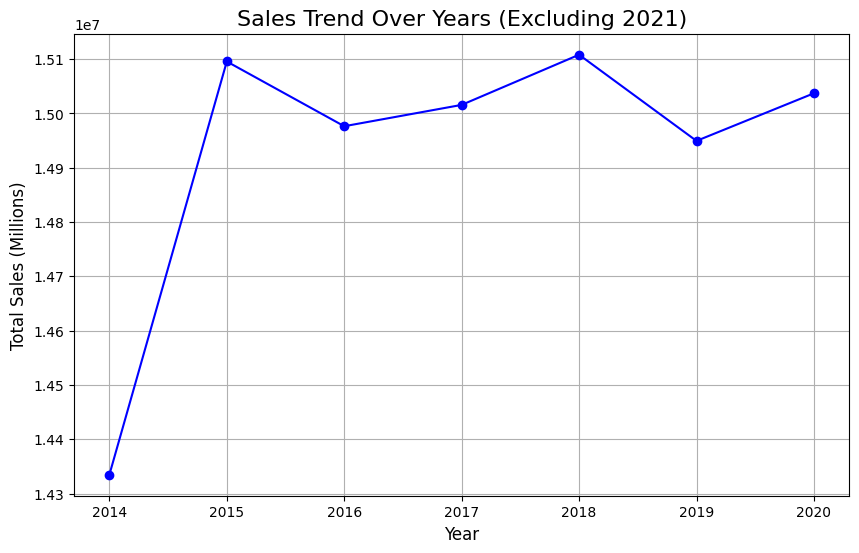

In [121]:
# Exclude the year 2021 and calculate total sales by year
sales_trend = df[df['year'] != 2021].groupby('year')['total_price'].sum().reset_index()

# Plot the sales trend
plt.figure(figsize=(10, 6))
plt.plot(sales_trend['year'], sales_trend['total_price'], marker='o', linestyle='-', color='b')
plt.title('Sales Trend Over Years (Excluding 2021)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Sales (Millions)', fontsize=12)
plt.grid(True)
plt.show()

In [122]:
df['bank_name'].value_counts()

bank_name
AB Bank Limited                                       26046
South Bangla Agriculture and Commerce Bank Limited    25964
NRB Bank Limited                                      25887
Rocket                                                25865
Standard Bank Limited                                 25853
National Credit & Commerce Bank Limited               25849
Dhaka Bank Limited                                    25839
Bangladesh Commerce Bank Limited                      25787
City Bank Limited                                     25774
Bengal Commercial Bank Ltd                            25762
Modhumoti Bank Limited                                25749
Bkash                                                 25678
Meghna Bank Limited                                   25670
Trust Bank Limited                                    25661
Premier Bank Limited                                  25652
Shimanto Bank Ltd                                     25649
IFIC Bank Limited             

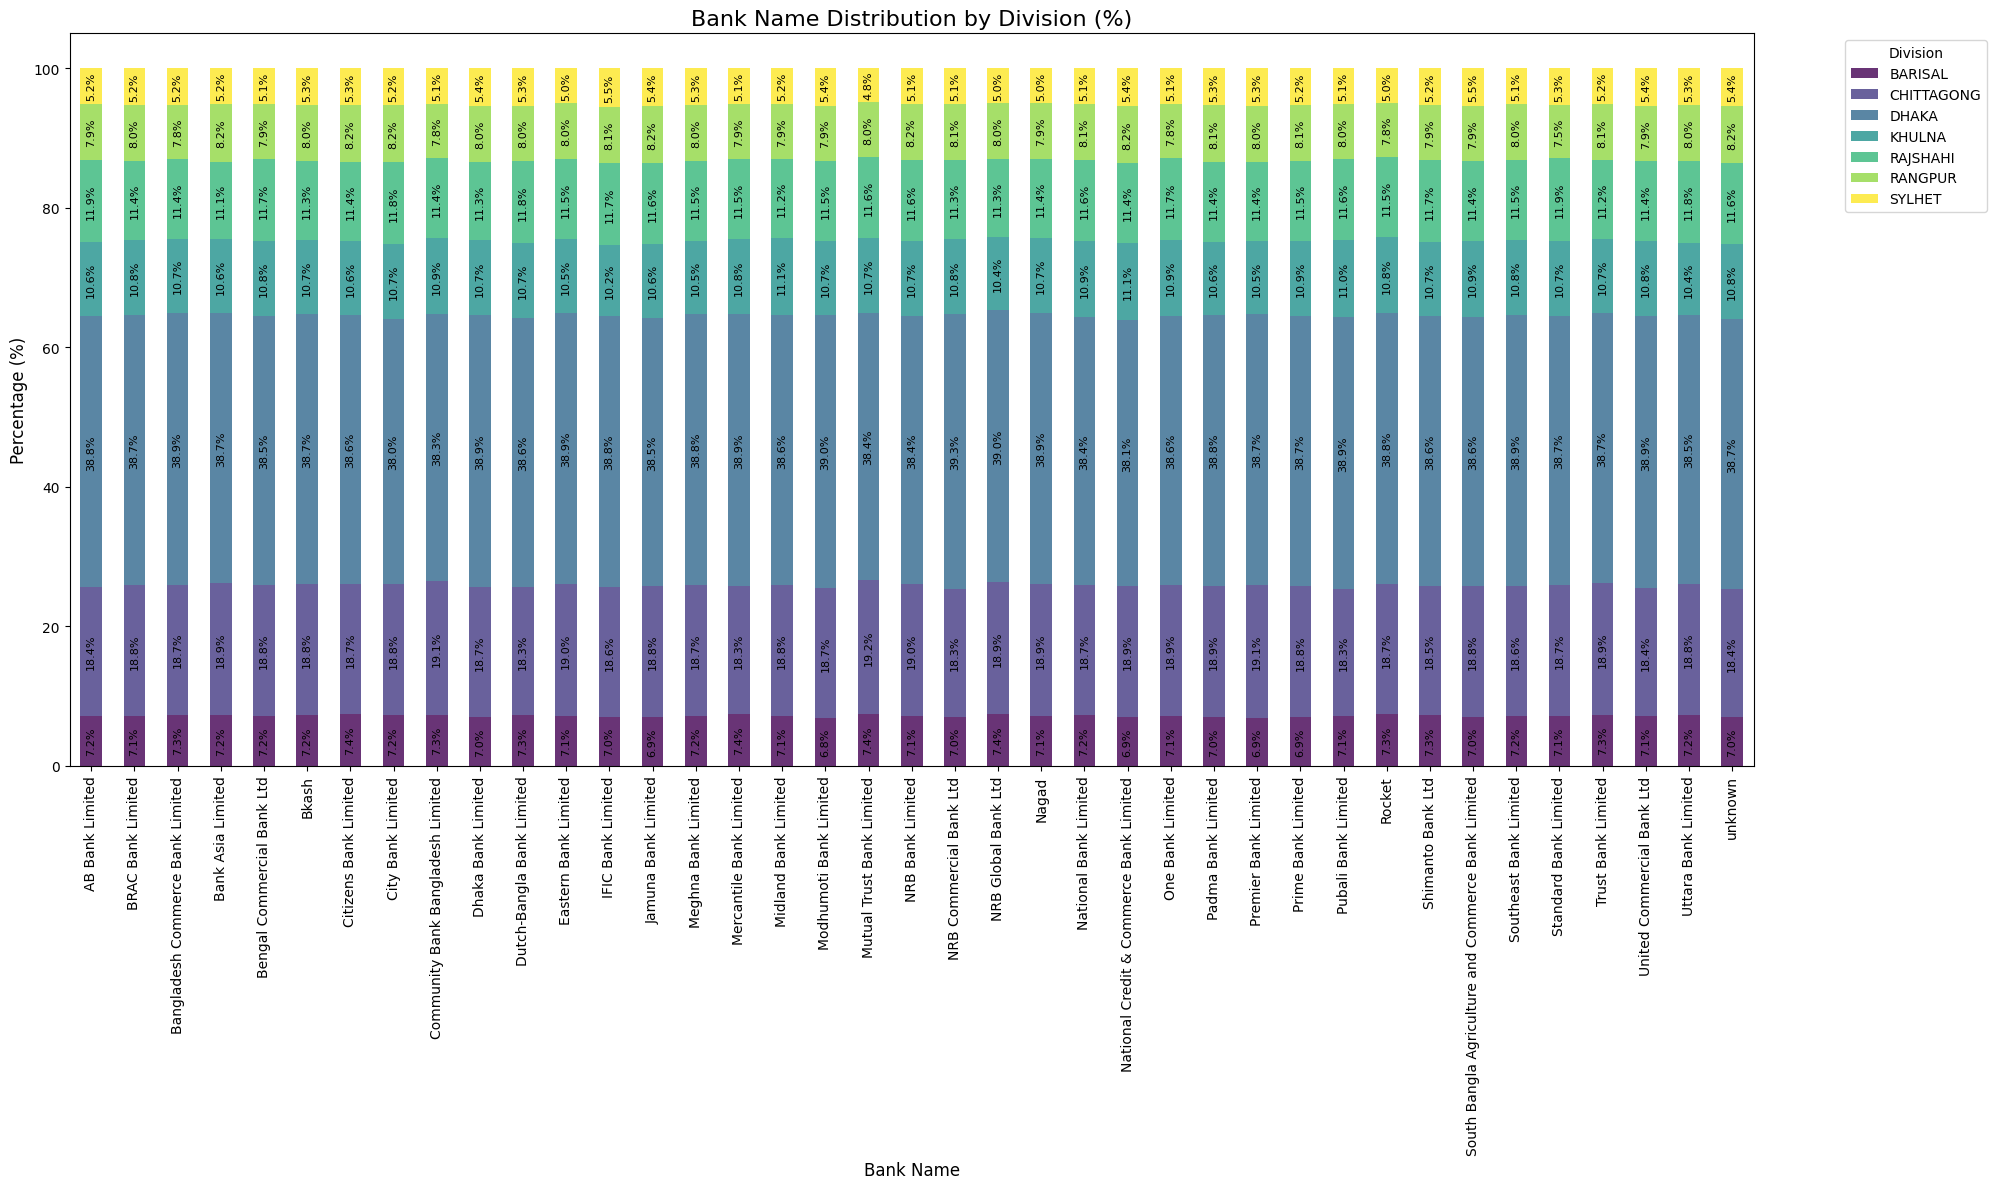

In [123]:
# Group by bank_name and division, and count occurrences
bank_division_count = df.groupby(['bank_name', 'division']).size().reset_index(name='count')

# Pivot the data for better visualization
bank_division_pivot = bank_division_count.pivot(index='bank_name', columns='division', values='count').fillna(0)

# Calculate percentages
bank_division_pivot_percentage = bank_division_pivot.div(bank_division_pivot.sum(axis=1), axis=0) * 100

# Plot the stacked bar chart
ax = bank_division_pivot_percentage.plot(kind='bar', stacked=True, figsize=(20, 12), colormap='viridis', alpha=0.8)
plt.title('Bank Name Distribution by Division (%)', fontsize=16)
plt.xlabel('Bank Name', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Division', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=90)

# Annotate percentages on the bars
for bar_group in ax.containers:
    for bar in bar_group:
        if bar.get_height() > 0:  # Avoid annotating zero values
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f'{bar.get_height():.1f}%',
                ha='center',
                va='center',
                fontsize=8,
                color='black',
                rotation=90
            )

plt.tight_layout()
plt.show()

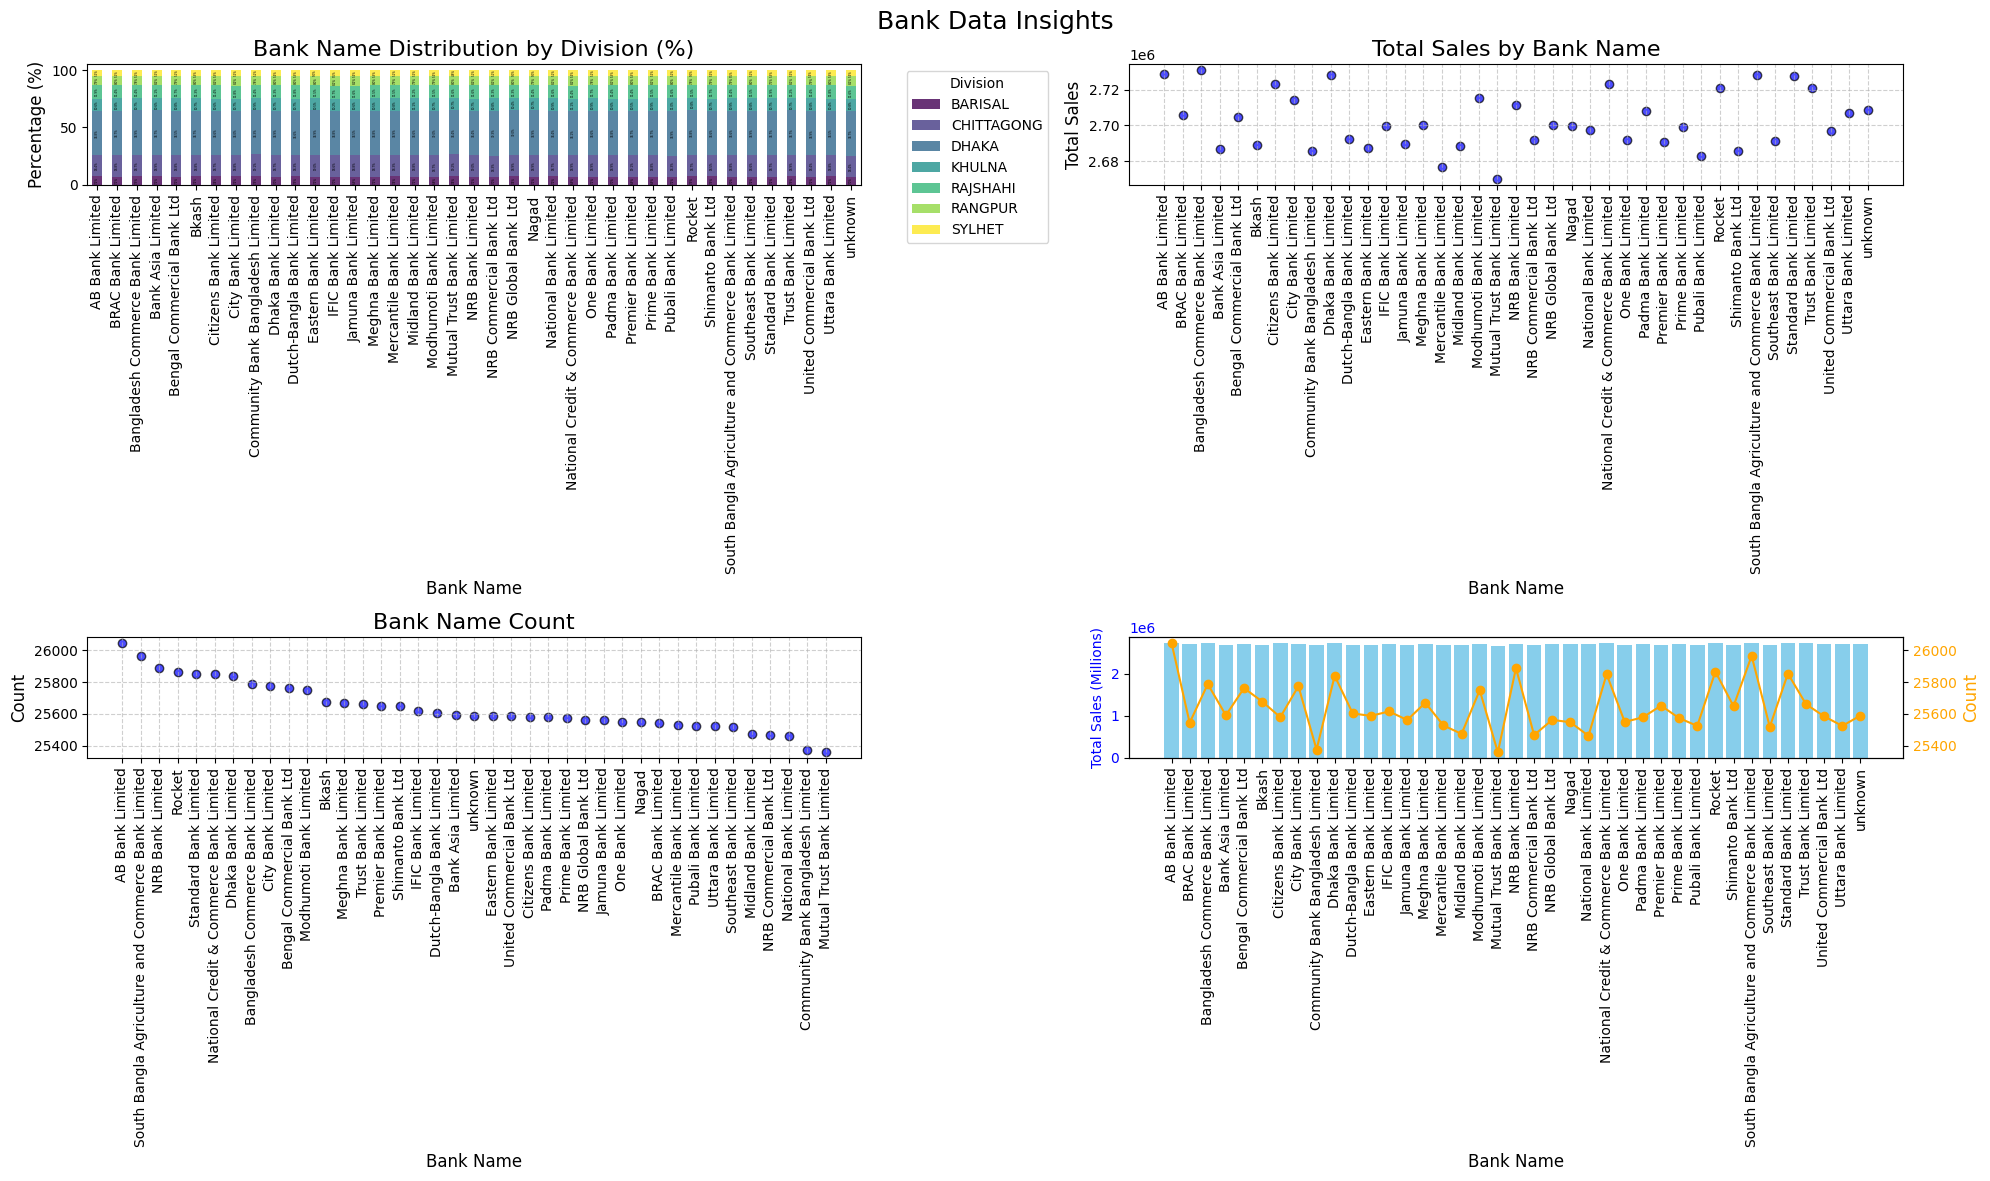

In [124]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(20, 12))  # 2x2 layout

# 📊 **1st Plot: Bank Name Distribution by Division (Stacked Bar Chart)**
bank_division_pivot_percentage.plot(kind='bar', stacked=True, ax=axes[0, 0], colormap='viridis', alpha=0.8)
axes[0, 0].set_title('Bank Name Distribution by Division (%)', fontsize=16)
axes[0, 0].set_xlabel('Bank Name', fontsize=12)
axes[0, 0].set_ylabel('Percentage (%)', fontsize=12)
axes[0, 0].legend(title='Division', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 0].tick_params(axis='x', rotation=90)
# Annotate percentages on the bars
for bar_group in axes[0, 0].containers:
    for bar in bar_group:
        if bar.get_height() > 0:  # Avoid annotating zero values
            axes[0, 0].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f'{bar.get_height():.1f}%',
                ha='center',
                va='center',
                fontsize=2,
                color='black',
                rotation=90
            )

# 📈 **2nd Plot: Total Sales by Bank Name (Scatter Plot)**
# Group by bank_name and calculate total sales
bank_sales = df.groupby('bank_name')['total_price'].sum().reset_index()
axes[0, 1].scatter(bank_sales['bank_name'], bank_sales['total_price'], color='b', alpha=0.7, edgecolors='black')
# Add labels and title
axes[0, 1].set_title('Total Sales by Bank Name', fontsize=16)
axes[0, 1].set_xlabel('Bank Name', fontsize=12)
axes[0, 1].set_ylabel('Total Sales', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=90)
axes[0, 1].grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 📈 **3rd Plot: Bank Name Count (Scatter Plot)**
bank_name_counts = df['bank_name'].value_counts()
axes[1, 0].scatter(bank_name_counts.index, bank_name_counts.values, color='b', alpha=0.7, edgecolors='black')
# Set title and axis labels
axes[1, 0].set_title('Bank Name Count', fontsize=16)
axes[1, 0].set_xlabel('Bank Name', fontsize=12)
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=90)
axes[1, 0].grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 📊 **4th Plot: Bank Name by Total Sales & Count**
bank_stats = df.groupby('bank_name').agg({'total_price': 'sum', 'bank_name': 'count'}).rename(columns={'bank_name': 'count'}).reset_index()
ax3 = axes[1, 1]
ax3.bar(bank_stats['bank_name'], bank_stats['total_price'], color='skyblue', label='Total Sales')
ax3.set_xlabel('Bank Name', fontsize=12)
ax3.set_ylabel('Total Sales (Millions)', fontsize=10, color='blue')
ax3.tick_params(axis='y', labelcolor='blue')
ax3.tick_params(axis='x', rotation=90)

# Secondary Y-axis for count
ax4 = ax3.twinx()
ax4.plot(bank_stats['bank_name'], bank_stats['count'], color='orange', marker='o', label='Count')
ax4.set_ylabel('Count', fontsize=12, color='orange')
ax4.tick_params(axis='y', labelcolor='orange')

# 🏆 **Final Adjustments**
fig.suptitle('Bank Data Insights', fontsize=18)
fig.tight_layout()
plt.show()

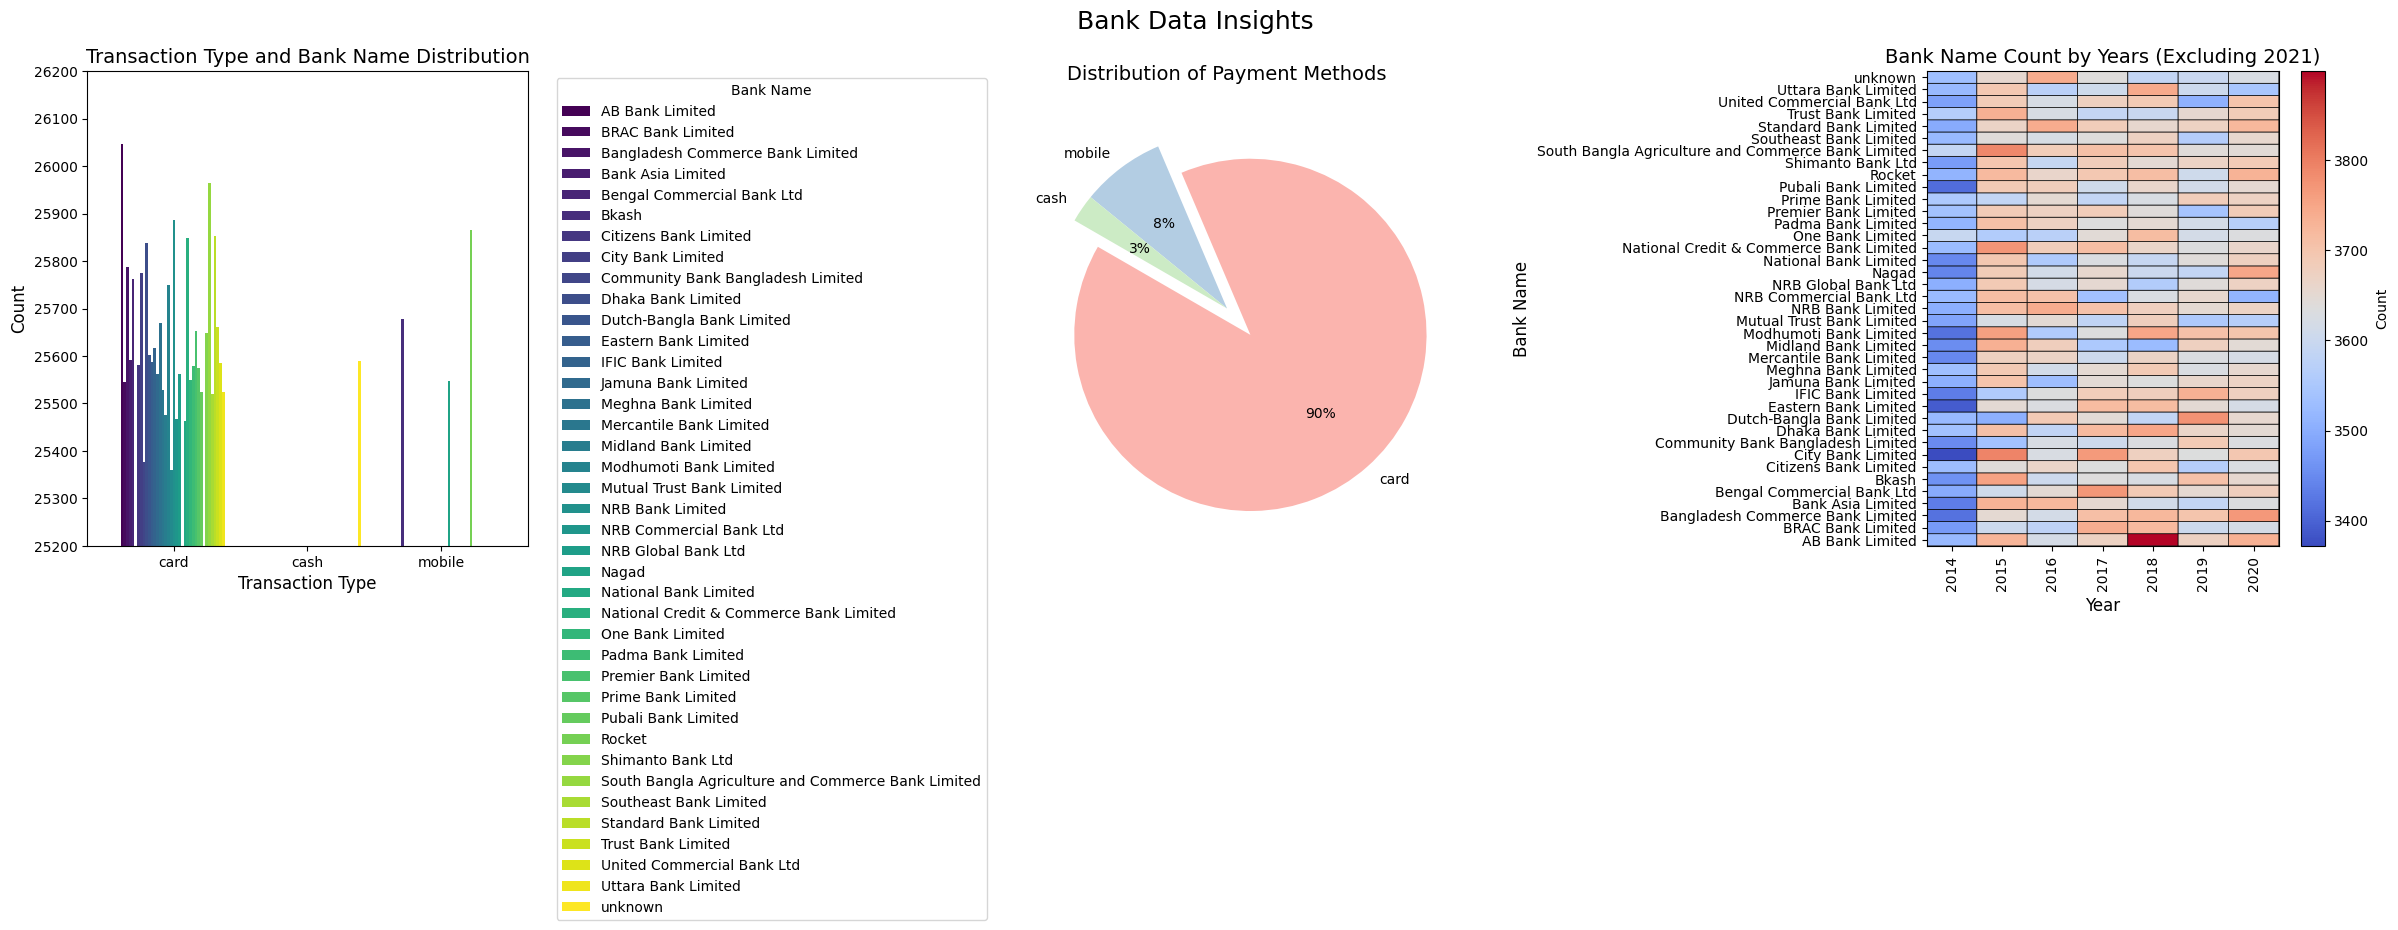

In [125]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))  # Create a 1-row, 3-column layout

# 📊 **1st Plot: Transaction Type and Bank Name Distribution (Grouped Bar Chart)**
trans_bank_count = df.groupby(['trans_type', 'bank_name']).size().unstack(fill_value=0)
trans_bank_count.plot(kind='bar', ax=axes[0], colormap='viridis', width=0.8)

axes[0].set_ylim(25200, 26200) # Set the y-axis limits between 25000 and 25400
axes[0].set_yticks(np.arange(25200, 26201, 100)) # Set intervals of 100 (25000, 25100, 25200, 25300, 25400)
axes[0].set_title('Transaction Type and Bank Name Distribution', fontsize=14)
axes[0].set_xlabel('Transaction Type', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(title='Bank Name', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=0)

# 📊 **2nd Plot: Payment Methods Distribution (Pie Chart)**
pay_method = df['trans_type'].value_counts().reset_index()
explode = [0.2, 0, 0]  # Adjust for highlighting first slice
axes[1].pie(pay_method['count'], labels=pay_method['trans_type'], autopct='%1.0f%%', explode=explode,
            startangle=150, colors=sns.color_palette('Pastel1'))
axes[1].set_title('Distribution of Payment Methods', fontsize=14)

# 📊 **3rd Plot: Bank Name Count by Years (Excluding 2021) (Heatmap)**
filtered_data = df[df['year'] != 2021]
bank_year_count = filtered_data.groupby(['bank_name', 'year']).size().unstack(fill_value=0)
im = axes[2].pcolor(bank_year_count, cmap='coolwarm', edgecolors='k', linewidths=0.5)
fig.colorbar(im, ax=axes[2], label='Count')
axes[2].set_xticks(np.arange(0.5, len(bank_year_count.columns), 1))
axes[2].set_xticklabels(bank_year_count.columns, rotation=90)
axes[2].set_yticks(np.arange(0.5, len(bank_year_count.index), 1))
axes[2].set_yticklabels(bank_year_count.index)
axes[2].set_title('Bank Name Count by Years (Excluding 2021)', fontsize=14)
axes[2].set_xlabel('Year', fontsize=12)
axes[2].set_ylabel('Bank Name', fontsize=12)

# 🏆 **Final Adjustments**
fig.suptitle('Bank Data Insights', fontsize=18)
fig.tight_layout()
plt.show()

*Summary of the Transaction over banks for ECommerce.*
* Based on the data insights from E-Commerce transactions, AB Bank Limited has the highest usage count in Dhaka Division, which also stands out as the region with the most transactions overall. However, Bangladesh Commerce Bank Limited recorded the highest transaction amount.
* Between 2014 and 2020, transaction usage showed a gradual increase, reaching its peak in 2018. Additionally, nearly 90% of customers prefer card payment methods when conducting transactions with AB Bank Limited.

### Create New Data_frame and categorized the 'desc' column for food Type

* overview the value of desc column in df.
* categorized "food", "Beverage", "Coffee and ingredient", "Dishware", "Kitchen Supplies" and so on.

In [126]:
print(df['desc'].value_counts())

desc
a. Beverage - Soda             109741
Food - Healthy                 109585
Food - Chips                    79676
a. Beverage Sparkling Water     79353
Kitchen Supplies                72416
Food - Chocolate                52758
Beverage - Energy/Protein       49300
Food - Sweets                   41747
Beverage - Gatorade             37713
Beverage Water                  34173
Coffee Sweetener                30511
Gum - Mints                     30237
Beverage - Juice                26865
Coffee K-Cups                   26671
Beverage - Iced Tea             26517
Food - Nuts                     22846
Dishware - Cups Hot             22834
Coffee Cream                    22702
Dishware - Plates               22538
Food - Snacks                   18942
Coffee Ground                   18901
Dishware - Cups Cold            11369
Dishware - Utensils             11206
Coffee Hot Cocoa                 7585
Coffee Creamer                   7584
Medicine                         7575
Dishwar

In [127]:
%load_ext sql
# Connect to the SQLite database using the %sql magic
%sql sqlite:///ECommerce_DataBase.db

df.to_sql('df', con, if_exists='replace', index=False)
# Corrected SQL Query
item_description = """
SELECT 
    man_country,
    SUM(quantity) AS Total_Qty, 
    SUM(total_price) AS Total_Sale, 
    supplier, 
    item_key,
    desc, 
    trans_type AS payment,
    bank_name,
    supplier,
    division,
    district,
    year,
    CASE 
        WHEN desc LIKE '%Food%' THEN 'Food' 
        WHEN desc LIKE '%Beverage%' THEN 'Beverage' 
        WHEN desc LIKE '%Coffee%' THEN 'Coffee and ingredients'
        WHEN desc LIKE '%Dishware%' THEN 'Dishware' 
        WHEN desc LIKE '%Kitchen%' THEN 'Kitchen Supplies' 
        WHEN desc LIKE '%Medicine%' THEN 'Medicine' 
        ELSE 'GUM' 
    END AS food_type
FROM df
GROUP BY man_country, food_type
ORDER BY Total_Sale DESC;
"""

# Execute the query
result_item_description = pd.read_sql_query(item_description, con)

# Print result
print(result_item_description)

# Close the connection
con.close()

The sql extension is already loaded. To reload it, use:
  %reload_ext sql
      man_country  Total_Qty  Total_Sale                        supplier  \
0           India     365007  5897572.00       Indo Count Industries Ltd   
1         Germany     314698  4950238.00              Friedola 1888 GmbH   
2      Bangladesh     250691  4808845.00                    DENIMACH LTD   
3       Lithuania     250917  4798933.50                        BIGSO AB   
4      Bangladesh     270273  4393681.50                    DENIMACH LTD   
5          poland     251012  4260231.50              CHROMADURLIN S.A.S   
6          poland     226230  3896075.00              CHROMADURLIN S.A.S   
7     Netherlands     229446  3805810.00                 Bolsius Boxmeer   
8        Cambodia     249120  3774939.00  NINGBO SEDUNO IMP & EXP CO.LTD   
9     Netherlands     226256  3747311.00                 Bolsius Boxmeer   
10          India      92072  3718163.00       Indo Count Industries Ltd   
11  United Sta

In [128]:
result_item_description.info()

<class 'pandas.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   man_country  57 non-null     str    
 1   Total_Qty    57 non-null     int64  
 2   Total_Sale   57 non-null     float64
 3   supplier     57 non-null     str    
 4   item_key     57 non-null     str    
 5   desc         57 non-null     str    
 6   payment      57 non-null     str    
 7   bank_name    57 non-null     str    
 8   supplier     57 non-null     str    
 9   division     57 non-null     str    
 10  district     57 non-null     str    
 11  year         57 non-null     int64  
 12  food_type    57 non-null     str    
dtypes: float64(1), int64(2), str(10)
memory usage: 5.9 KB


In [129]:
# result_item_description.to_csv("result_item_description.csv", index=False)

In [130]:
result_item_description.head()

,man_country,Total_Qty,Total_Sale,supplier,item_key,desc,payment,bank_name,supplier,division,district,year,food_type
0,India,365007,5897572.0,Indo Count Industries Ltd,I00214,Food - Nuts,card,Bengal Commercial Bank Ltd,Indo Count Industries Ltd,RAJSHAHI,BOGRA,2018,Food
1,Germany,314698,4950238.0,Friedola 1888 GmbH,I00225,Food - Sweets,card,NRB Commercial Bank Ltd,Friedola 1888 GmbH,BARISAL,BARISAL,2017,Food
2,Bangladesh,250691,4808845.0,DENIMACH LTD,I00039,a. Beverage Sparkling Water,card,Shimanto Bank Ltd,DENIMACH LTD,RAJSHAHI,PABNA,2015,Beverage
3,Lithuania,250917,4798933.5,BIGSO AB,I00010,a. Beverage - Soda,card,IFIC Bank Limited,BIGSO AB,KHULNA,KHULNA,2017,Beverage
4,Bangladesh,270273,4393681.5,DENIMACH LTD,I00192,Food - Healthy,card,Dutch-Bangla Bank Limited,DENIMACH LTD,CHITTAGONG,RANGAMATI,2019,Food


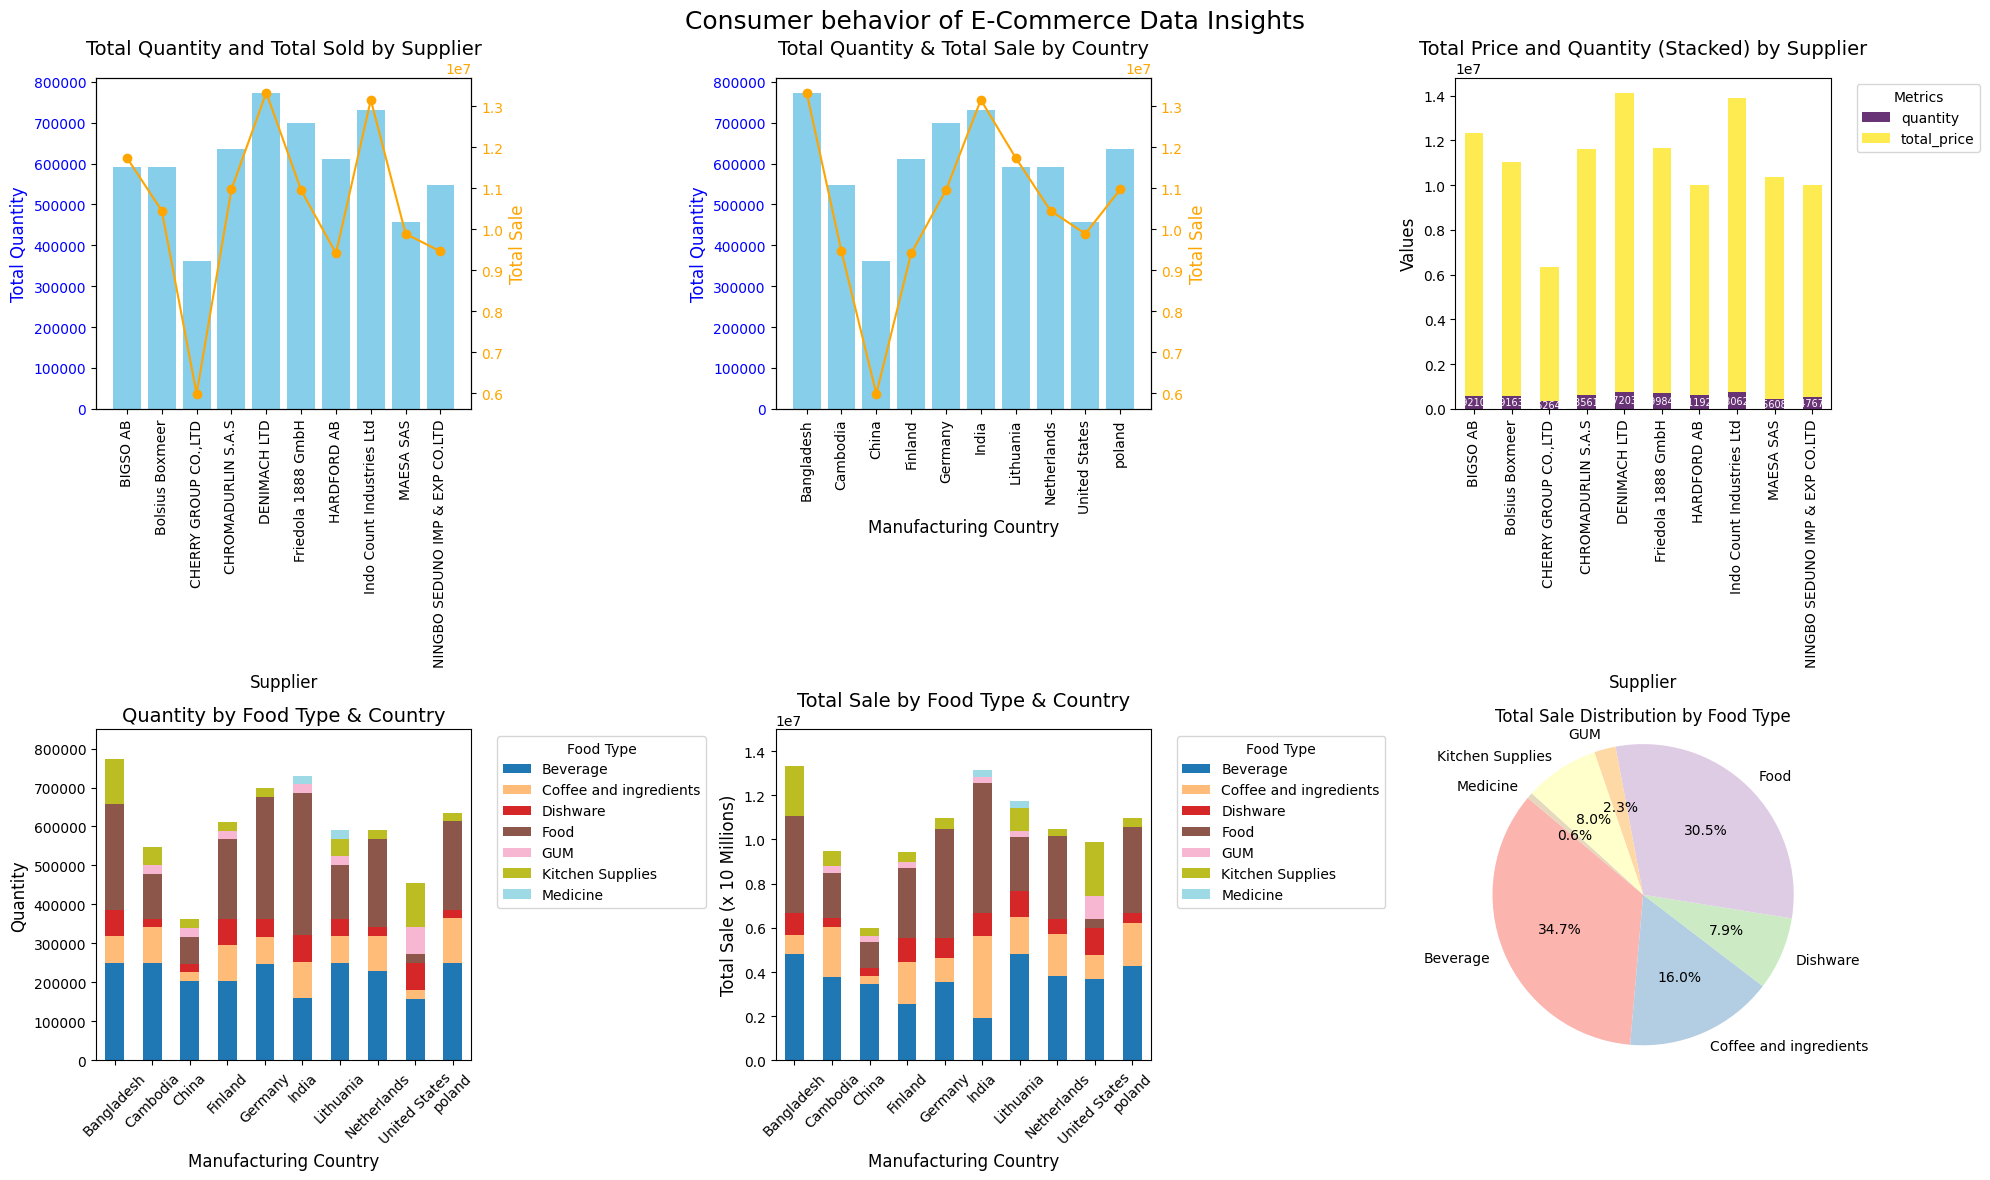

In [137]:
import matplotlib.pyplot as plt

# Create qty_pivot before plotting
qty_pivot = result_item_description.pivot_table(
    index='man_country',
    columns='food_type',
    values='Total_Qty',
    aggfunc='sum',
    fill_value=0
)

# Create sale_pivot before plotting
sale_pivot = result_item_description.pivot_table(
    index='man_country',
    columns='food_type',
    values='Total_Sale',
    aggfunc='sum',
    fill_value=0
)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))  # Create a 2x3 grid layout

# 📊 **1st Plot: Total Quantity and Total Sold by Supplier**
supplier_summary = df.groupby('supplier').agg(quantity=('quantity', 'sum'), total_price=('total_price', 'sum')).reset_index()
ax1 = axes[0, 0]
ax1.bar(supplier_summary['supplier'], supplier_summary['quantity'], color='skyblue', label='Total Quantity')
ax1.set_xlabel('Supplier', fontsize=12)
ax1.set_ylabel('Total Quantity', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.tick_params(axis='x', rotation=90)
ax2 = ax1.twinx()
ax2.plot(supplier_summary['supplier'], supplier_summary['total_price'], color='orange', marker='o', label='Total Sale')
ax2.set_ylabel('Total Sale', fontsize=12, color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
ax1.set_title('Total Quantity and Total Sold by Supplier', fontsize=14)

# 📊 **2nd Plot: Total Quantity vs Total Sale by Manufacturing Country**
country_sales_qty = result_item_description.groupby('man_country')[['Total_Sale', 'Total_Qty']].sum().reset_index()
ax3 = axes[0, 1]
ax3.bar(country_sales_qty['man_country'], country_sales_qty['Total_Qty'], color='skyblue', label='Total Quantity')
ax3.set_xlabel('Manufacturing Country', fontsize=12)
ax3.set_ylabel('Total Quantity', fontsize=12, color='blue')
ax3.tick_params(axis='y', labelcolor='blue')
ax3.tick_params(axis='x', rotation=90)
ax4 = ax3.twinx()
ax4.plot(country_sales_qty['man_country'], country_sales_qty['Total_Sale'], color='orange', marker='o', label='Total Sale')
ax4.set_ylabel('Total Sale', fontsize=12, color='orange')
ax4.tick_params(axis='y', labelcolor='orange')
ax3.set_title('Total Quantity & Total Sale by Country', fontsize=14)

# 📊 **3rd Plot: Stacked Bar Chart for Total_Qty & Total_Sale by Supplier**
# Prepare supplier_data by grouping df
supplier_data = df.groupby('supplier').agg({'quantity': 'sum', 'total_price': 'sum'}).reset_index()
supplier_data.set_index('supplier')[['quantity', 'total_price']].plot(
    kind='bar', stacked=True, ax=axes[0, 2], colormap='viridis', alpha=0.8
)

# Add labels and title, adjust legend title box next to graph 
axes[0, 2].set_title('Total Price and Quantity (Stacked) by Supplier', fontsize=14)
axes[0, 2].set_xlabel('Supplier', fontsize=12)
axes[0, 2].set_ylabel('Values', fontsize=12)
axes[0, 2].tick_params(axis='x', rotation=90)
axes[0, 2].legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')

# Annotate quantity values on bars
for index, row in supplier_data.iterrows():
    axes[0, 2].text(
        x=index,
        y=row['quantity'] / 2, 
        s=f"{row['quantity']}",
        ha='center',
        va='center',
        rotation=0,
        fontsize=7,
        color='white'
    )

# Final layout adjustments
plt.tight_layout()

# 📊 4th Plot: Quantity by Food Type and Country (Stacked Bar Chart)
qty_pivot.plot(kind='bar', stacked=True, ax=axes[1, 0], colormap='tab20')
axes[1, 0].set_title('Quantity by Food Type & Country', fontsize=14)
axes[1, 0].set_xlabel('Manufacturing Country', fontsize=12)
axes[1, 0].set_ylabel('Quantity', fontsize=12)
axes[1, 0].legend(title='Food Type', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 0].tick_params(axis='x', rotation=45)

# 💡 ဖြေရှင်းချက်- ဘယ်ဘက် Graph အတွက် y-axis အမြင့်ဆုံးတန်ဖိုးကို 850,000 သို့ ကိုယ်တိုင်သတ်မှတ်လိုက်ခြင်း
axes[1, 0].set_ylim(0, 850000)

# ----------------------------------------------------------------------

# 📊 5th Plot: Total Sale by Food Type and Country (Stacked Bar Chart)
sale_pivot.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap='tab20')
axes[1, 1].set_title('Total Sale by Food Type & Country', fontsize=14)
axes[1, 1].set_xlabel('Manufacturing Country', fontsize=12)
axes[1, 1].set_ylabel('Total Sale (x 10 Millions)', fontsize=12)
axes[1, 1].legend(title='Food Type', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 1].tick_params(axis='x', rotation=45)

# 💡 ဖြေရှင်းချက်- ညာဘက် Graph အတွက် y-axis အမြင့်ဆုံးတန်ဖိုးကို ၁၅ သန်း (1.5e7) သို့ ကိုယ်တိုင်သတ်မှတ်လိုက်ခြင်း
axes[1, 1].set_ylim(0, 15000000)

# 💡 Graph တစ်ခုလုံး နေရာလွတ် သပ်ရပ်သွားစေရန်
plt.tight_layout()



# 📊 **6th Plot: Pie chart for Total_Sale by food_type**
food_type_data = result_item_description.groupby('food_type')['Total_Sale'].sum()
axes[1, 2].pie(
    food_type_data.values,
    labels=food_type_data.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Pastel1.colors
)
axes[1, 2].set_title('Total Sale Distribution by Food Type')
axes[1, 2].axis('equal')

# 🏆 **Final Adjustments**
fig.suptitle('Consumer behavior of E-Commerce Data Insights', fontsize=18)
fig.tight_layout()
plt.show()


## *Conclusion: Customer Behavior Insights from E-Commerce Data*
The analysis of e-commerce transactions reveals key patterns in customer preferences, supplier impact, and purchasing behavior. Here are the main findings:

1️⃣ Customer Preferences in Transactions
- AB Bank Limited dominates transaction volume, especially in Dhaka Division, which is the most active region.
- Total sales remain consistently high and evenly distributed across most major commercial banks, with AB Bank Limited maintaining top-tier financial performance.
- Nearly 90% of transactions are conducted via card payments, reinforcing the preference for digital transactions over mobile and cash.
 
2️⃣ Supplier and Country-Level Insights
- Bangladesh, India, and Poland emerge as top countries for both manufacturing and total sales, suggesting strong supply chain involvement.
- DENIMACH LTD and Indo Count Industries Ltd are among the highest-performing suppliers in terms of total quantity sold.
- Some countries, like China and Cambodia, have relatively lower total sales, indicating weaker customer engagement.

3️⃣ Food Type Preferences
- Beverage products dominate, accounting for 34.7% of total sales, followed closely by Food (30.5%) and Coffee and ingredients (16.0%).
- Dishware makes up only 7.9%, suggesting lower demand compared to core consumables.
- Certain countries specialize in specific food types—for instance, India leads in Coffee sales, while Bangladesh shows a massive footprint in food processing lines.

4️⃣ Market Trends Over Time
- E-commerce transactions steadily increased between 2014 and 2020, peaking in 2017–2018 before stabilizing.
- The growing preference for digital transactions and regional purchasing trends indicate changing customer behavior toward online commerce.

Key Takeaways for Business Strategy

*📌* Focus on regions with strong transaction volume, like Dhaka Division, for targeted banking strategies.
*📌* Leverage digital payment methods, as card transactions continue to heavily dominate at 90% market share.
*📌* Strengthen supplier partnerships with high-performing companies like DENIMACH LTD and Indo Count Industries Ltd.
*📌* Expand marketing efforts for beverage and food categories, which show the highest consumer demand.
*📌* Monitor e-commerce growth trends and adjust supply chain strategies to capitalize on peak purchasing years.

These insights help businesses optimize product offerings, tailor marketing efforts, and enhance supply chain efficiency to better align with customer behavior in e-commerce markets.
"""


"""
## 🎯 Project Alignment: Objectives vs. Achievements

### 1️⃣ Objective: Utilize data visualization to reveal patterns in sales, customer preferences, and product demand, without deep statistical analysis.
* **Status:** **Yes (Achieved)**
* **Achievement:**  bypassed complex statistical formulas by leveraging clear, intuitive visualizations to uncover key business patterns:
  * 📦 **Product Demand:** Used a **Pie Chart** to instantly isolate that **Beverages (34.7%)** and **Food (30.5%)** drive the absolute majority of consumer demand.
  * 🗓️ **Temporal Trends:** Deployed a **Heatmap** to show transaction density, revealing that e-commerce velocity steadily built up and plateaued during the **2017–2018** operational cycles.
  * 🌍 **Supply Chain Volume:** Utilized **Stacked Bar Charts** to immediately identify which global hubs anchor production volume without requiring advanced sampling statistics.

---

### 2️⃣ Objective: Identify growth opportunities by analyzing transaction behaviors across different dimensions.
* **Status:** **Yes (Achieved)**
* **Achievement:** used SQL `LEFT JOIN` structures to transform flat data into a comprehensive Star Schema, unlocking multiple transactional dimensions for behavior analysis:
  * 🗺️ **Geographical Dimension:** Discovered that **Dhaka Division** is a high-velocity cluster, marking it as a prime geographical corridor for expansion.
  * 💳 **Payment Method Dimension:** Revealed a near-total consumer shift toward digital methods, discovering that **~90%** of all transactions rely on digitized card payment structures.
  * 🏭 **Supplier Performance Dimension:** Isolated high-performing manufacturing vendors, specifically identifying **DENIMACH LTD** and **Indo Count Industries Ltd** as absolute volume leaders.

---

### 3️⃣ Objective: Offer actionable recommendations that can help businesses refine their strategies, improve sales performance, and enhance customer engagement.
* **Status:** **Yes (Achieved)**
* **Achievement:** translated the visual data insights into **Strategy 01 through Strategy 04**, delivering specific business-backed growth frameworks:
  * 📈 **Refining Strategy:** Recommended channeling digital marketing allocations directly into the most profitable product sectors—specifically **Beverages** and **Food** vectors.
  * 📊 **Improving Sales Performance:** Suggested deploying targeted co-branding frameworks specifically inside high-density zones like **Dhaka Division** to capture immediate transactional footprints.
  * 💻 **Enhancing Customer Engagement:** Proposed optimizing the checkout infrastructure to remove friction from card payments, directly matching the observed **90% cashless momentum**.
"""
